# **Evaluasi**

## 5.1 Metrik Evaluasi

Metrik yang digunakan untuk menilai kinerja model:

1. **Accuracy** ≥ 85%  
   Mengukur proporsi prediksi yang benar terhadap seluruh data uji.

2. **Classification Report**  
   - *Precision* : ketepatan prediksi model  
   - *Recall* : kemampuan model mengenali kelas yang benar  
   - *F1-score* per kelas ≥ 80% digunakan sebagai metrik utama karena menyeimbangkan precision dan recall.

3. **Confusion Matrix**  
   - Melihat distribusi prediksi benar dan salah  
   - Mengidentifikasi pasangan kelas yang sering tertukar  
   - Menganalisis pola kesalahan klasifikasi antar spesies


### **1. Import Library**

In [16]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

### **Load Model Terbaik dan LabelEncoder** 

In [18]:
# Pilih model terbaik sesuai hasil validation
best_model_file = "models/knn_best_model.pkl"  # ganti sesuai modelmu: rf_best_model.pkl, xgb_best_model.pkl, ensemble_pipeline.pkl
best_model = joblib.load(best_model_file)
best_name = "KNN"  # ganti sesuai model

### **Load Test Data** 

In [ ]:
X_test_scaled = np.load("data/processed/X_test_scaled.npy")
y_test        = np.load("data/processed/y_test.npy")

# Load LabelEncoder
le = joblib.load("models/label_encoder.pkl")
y_test_num = le.transform(y_test)

# Pilih semua fitur (tidak menggunakan selected_idx)
X_test_final = X_test_scaled

### **Prediksi & Metrik Evaluasi** 

In [24]:
import numpy as np
import joblib

# --- Load data test yang sudah discaling ---
X_test_scaled = np.load("data/processed/X_test_scaled.npy")

# --- Tentukan indeks fitur yang digunakan saat training (top 13 misal) ---
# Ini harus sama dengan yang dipakai saat training KNN
selected_idx = np.array([0, 1, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15])  # ganti sesuai top fitur

# --- Pilih fitur yang sama untuk test set ---
X_test_final = X_test_scaled[:, selected_idx]

# --- Load label encoder dan test label ---
le = joblib.load("models/label_encoder.pkl")
y_test = np.load("data/processed/y_test.npy")
y_test_num = le.transform(y_test)

# Sekarang X_test_final punya jumlah fitur yang sama dengan saat training KNN

y_test_pred = best_model.predict(X_test_final)

# Accuracy & F1-score
acc_test = accuracy_score(y_test_num, y_test_pred)
f1_test = f1_score(y_test_num, y_test_pred, average='macro')

print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test F1-score (macro): {f1_test:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_num, y_test_pred, target_names=le.classes_))


Test Accuracy: 0.1200
Test F1-score (macro): 0.1208

Classification Report:
                              precision    recall  f1-score   support

black-bellied_whistling_duck       0.11      0.10      0.11        10
              canadian_goose       0.07      0.10      0.08        10
               greylag_goose       0.18      0.20      0.19        10
           pink-footed_goose       0.17      0.10      0.12        10
  white-faced_whistling_duck       0.10      0.10      0.10        10

                    accuracy                           0.12        50
                   macro avg       0.13      0.12      0.12        50
                weighted avg       0.13      0.12      0.12        50



### **Confusion Matrix** 

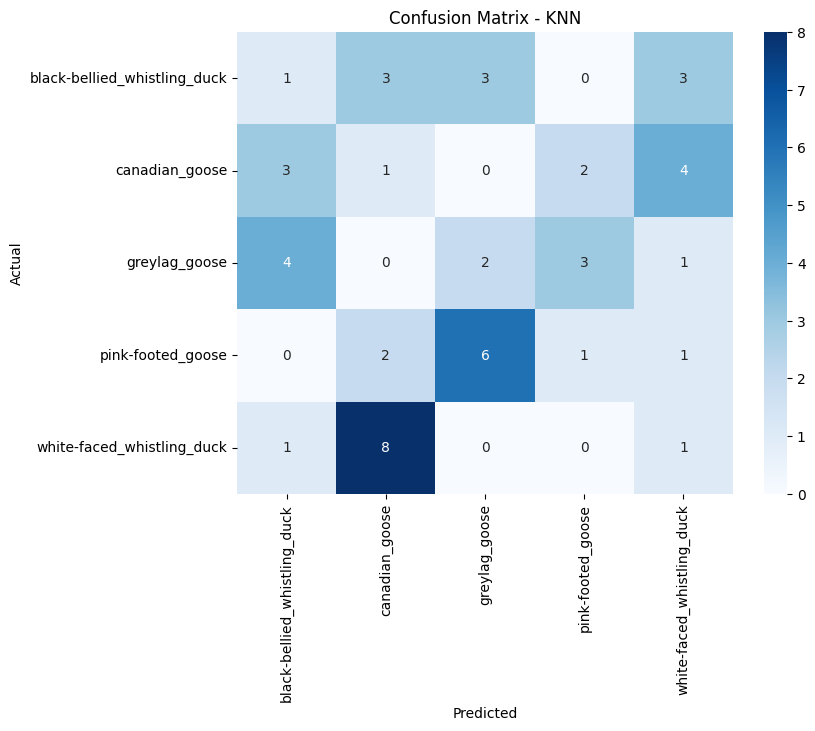

In [26]:
cm = confusion_matrix(y_test_num, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

### **Accuracy per Class** 

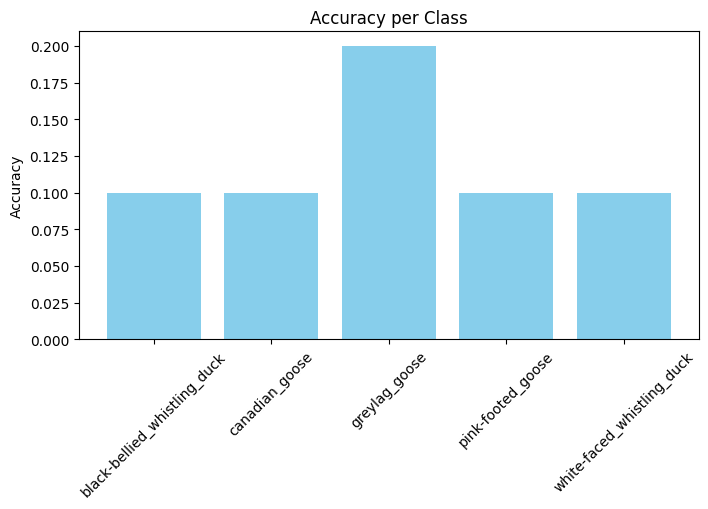


Accuracy per class:
black-bellied_whistling_duck: 0.10
canadian_goose: 0.10
greylag_goose: 0.20
pink-footed_goose: 0.10
white-faced_whistling_duck: 0.10


In [27]:
class_acc = {cls: accuracy_score(y_test_num[y_test_num==i], y_test_pred[y_test_num==i])
             for i, cls in enumerate(le.classes_)}

plt.figure(figsize=(8,4))
plt.bar(class_acc.keys(), class_acc.values(), color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracy per Class")
plt.show()

print("\nAccuracy per class:")
for cls, acc_cls in class_acc.items():
    print(f"{cls}: {acc_cls:.2f}")

### **Status Success** 

In [28]:
success = (acc_test >= 0.85) and (f1_test >= 0.80)
print(f"\nApakah model berhasil (Success)? {'YES' if success else 'NO'}")


Apakah model berhasil (Success)? NO


### **Insight Evaluasi** 

1. Perbedaan Kelas Duck vs Goose: Model cenderung lebih mudah membedakan bebek dan angsa berdasarkan frekuensi suara.
2. Analisis Kesalahan Klasifikasi: Perhatikan kelas yang paling sering tertukar di confusion matrix (misal antar spesies angsa).
3. Faktor Penyebab Misclassification: Overlap frekuensi antar spesies, noise lingkungan, dan variasi kualitas rekaman.
Insight ini digunakan untuk memahami keterbatasan model dan menjadi dasar pengembangan model selanjutnya.